# Employee Job Change Prediction

## Overview
This project analyzes the HR Analytics dataset to predict whether an employee is likely to change jobs.

## Tasks Performed
- Loaded and explored the dataset
- Handled missing values
- Encoded categorical features
- Performed feature engineering
- Prepared data for machine learning
- Built and evaluated a classification model

## Libraries Used
- Pandas
- NumPy
- Scikit-learn

## Goal
Predict employee job change based on demographic and professional information.

In [1]:
import pandas as pd 

In [2]:
df = pd.read_csv("aug_test.csv")

In [3]:
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours
0,32403,city_41,0.827,Male,Has relevent experience,Full time course,Graduate,STEM,9,<10,NaN,1,21
1,9858,city_103,0.920,Female,Has relevent experience,no_enrollment,Graduate,STEM,5,NaN,Pvt Ltd,1,98
2,31806,city_21,0.624,Male,No relevent experience,no_enrollment,High School,NaN,<1,NaN,Pvt Ltd,never,15
3,27385,city_13,0.827,Male,Has relevent experience,no_enrollment,Masters,STEM,11,10/49,Pvt Ltd,1,39
4,27724,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,10000+,Pvt Ltd,>4,72


In [4]:
df.shape 

(2129, 13)

In [5]:
df.describe()

,enrollee_id,city_development_index,training_hours
count,2129.000000,2129.000000,2129.000000
mean,16861.614843,0.824984,64.983091
std,9576.846029,0.125074,60.238660
min,3.000000,0.448000,1.000000
25%,8562.000000,0.698000,23.000000
50%,16816.000000,0.903000,47.000000
75%,25129.000000,0.920000,86.000000
max,33353.000000,0.949000,334.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2129 entries, 0 to 2128
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             2129 non-null   int64  
 1   city                    2129 non-null   object 
 2   city_development_index  2129 non-null   float64
 3   gender                  1621 non-null   object 
 4   relevent_experience     2129 non-null   object 
 5   enrolled_university     2098 non-null   object 
 6   education_level         2077 non-null   object 
 7   major_discipline        1817 non-null   object 
 8   experience              2124 non-null   object 
 9   company_size            1507 non-null   object 
 10  company_type            1495 non-null   object 
 11  last_new_job            2089 non-null   object 
 12  training_hours          2129 non-null   int64  
dtypes: float64(1), int64(2), object(10)
memory usage: 216.4+ KB


In [7]:
df.isnull().sum()

enrollee_id                 0
city                        0
city_development_index      0
gender                    508
relevent_experience         0
enrolled_university        31
education_level            52
major_discipline          312
experience                  5
company_size              622
company_type              634
last_new_job               40
training_hours              0
dtype: int64

In [8]:
categorical_cols = df.select_dtypes(include=['object']).columns

df[categorical_cols] = df[categorical_cols].fillna('Unknown')

In [9]:
df.isnull().sum()

enrollee_id               0
city                      0
city_development_index    0
gender                    0
relevent_experience       0
enrolled_university       0
education_level           0
major_discipline          0
experience                0
company_size              0
company_type              0
last_new_job              0
training_hours            0
dtype: int64

In [10]:
df.shape 

(2129, 13)

In [11]:
df.nunique(dropna=False)

enrollee_id               2129
city                       108
city_development_index      81
gender                       4
relevent_experience          2
enrolled_university          4
education_level              6
major_discipline             7
experience                  23
company_size                 9
company_type                 7
last_new_job                 7
training_hours             223
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df['company_size'] = df['company_size'].fillna('Unknown')
df['company_type'] = df['company_type'].fillna('Unknown')

df = df.dropna(subset=['experience', 'enrolled_university'])

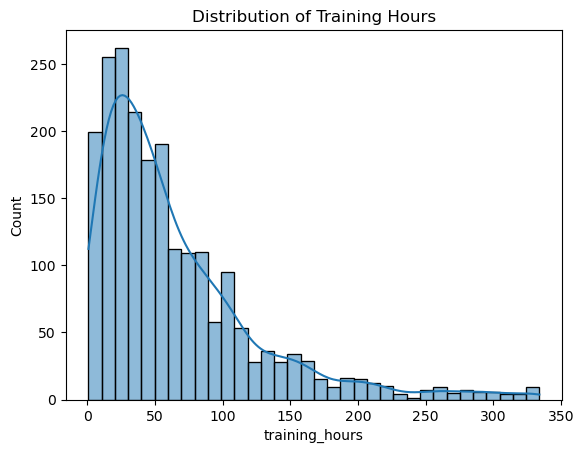

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['training_hours'], kde=True)
plt.title('Distribution of Training Hours')
plt.show()

In [15]:
df['education_level'].value_counts()

education_level
Graduate          1269
Masters            496
High School        222
Phd                 54
Unknown             52
Primary School      36
Name: count, dtype: int64

In [16]:
df['experience'].unique()

array(['9', '5', '<1', '11', '>20', '10', '14', '3', '20', '8', '4', '13',
       '2', '6', '7', '1', '19', '15', '16', 'Unknown', '17', '18', '12'],
      dtype=object)

In [17]:
print(df['experience'].unique())



['9' '5' '<1' '11' '>20' '10' '14' '3' '20' '8' '4' '13' '2' '6' '7' '1'
 '19' '15' '16' 'Unknown' '17' '18' '12']


In [18]:

df['experience'] = df['experience'].replace({'>20': '20', '<1': '0','Unknown':'0'})
df['experience'] = df['experience'].astype(float)

In [19]:
print(df['last_new_job'].unique())

['1' 'never' '>4' '2' '4' '3' 'Unknown']


In [20]:
df['last_new_job'] = df['last_new_job'].replace({'>4': '5', 'never': '0', 'Unknown': '0'})
df['last_new_job'] = df['last_new_job'].astype(float)

In [21]:
df['education_level'] = df['education_level'].map({
    'Primary School': 1,
    'High School': 2,
    'Graduate': 3,
    'Masters': 4,
    'Phd': 5,
    'Unknown': 0
})



In [22]:
df["gender"].unique()

array(['Male', 'Female', 'Unknown', 'Other'], dtype=object)

In [23]:
df["gender"] =df["gender"].map({
   'Female':0,
    'Male':1,
    'Unknown':2,
    'Other':3,

    
}) 

In [24]:
df['relevent_experience'].unique()

array(['Has relevent experience', 'No relevent experience'], dtype=object)

In [25]:
df['relevent_experience'].map({
    'Has relevent experience':1,
    'No relevent experience':0
    
})

0       1
1       1
2       0
3       1
4       1
       ..
2124    0
2125    1
2126    0
2127    1
2128    1
Name: relevent_experience, Length: 2129, dtype: int64

In [26]:
df['enrolled_university'].unique()

array(['Full time course', 'no_enrollment', 'Part time course', 'Unknown'],
      dtype=object)

In [27]:
df['enrolled_university'] = df['enrolled_university'].map({
    'no_enrollment': 0, 
    'Part time course': 1, 
    'Full time course': 2, 
    'Unknown': 0
})

In [28]:
df['company_size'].unique()

array(['<10', 'Unknown', '10/49', '10000+', '100-500', '50-99',
       '1000-4999', '500-999', '5000-9999'], dtype=object)

In [29]:
company_size_map = {
    'Unknown': 0, '<10': 1, '10/49': 2, '50-99': 3, 
    '100-500': 4, '500-999': 5, '1000-4999': 6, 
    '5000-9999': 7, '10000+': 8
}
df['company_size'] = df['company_size'].map(company_size_map).fillna(0).astype(int)

In [30]:
df['company_size'].unique()

array([1, 0, 2, 8, 4, 3, 6, 5, 7])

In [31]:
df['major_discipline'].unique()

array(['STEM', 'Unknown', 'Other', 'Business Degree', 'Arts',
       'Humanities', 'No Major'], dtype=object)

In [32]:
df['company_type'].unique()

array(['Unknown', 'Pvt Ltd', 'Funded Startup', 'Other', 'Public Sector',
       'Early Stage Startup', 'NGO'], dtype=object)

In [33]:
df = pd.get_dummies(df, columns=['major_discipline', 'company_type'], drop_first=True)

In [34]:
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,experience,company_size,last_new_job,...,major_discipline_No Major,major_discipline_Other,major_discipline_STEM,major_discipline_Unknown,company_type_Funded Startup,company_type_NGO,company_type_Other,company_type_Public Sector,company_type_Pvt Ltd,company_type_Unknown
0,32403,city_41,0.827,1,Has relevent experience,2,3,9.0,1,1.0,...,False,False,True,False,False,False,False,False,False,True
1,9858,city_103,0.920,0,Has relevent experience,0,3,5.0,0,1.0,...,False,False,True,False,False,False,False,False,True,False
2,31806,city_21,0.624,1,No relevent experience,0,2,0.0,0,0.0,...,False,False,False,True,False,False,False,False,True,False
3,27385,city_13,0.827,1,Has relevent experience,0,4,11.0,2,1.0,...,False,False,True,False,False,False,False,False,True,False
4,27724,city_103,0.920,1,Has relevent experience,0,3,20.0,8,5.0,...,False,False,True,False,False,False,False,False,True,False


In [35]:
df.shape

(2129, 23)

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2129 entries, 0 to 2128
Data columns (total 23 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   enrollee_id                       2129 non-null   int64  
 1   city                              2129 non-null   object 
 2   city_development_index            2129 non-null   float64
 3   gender                            2129 non-null   int64  
 4   relevent_experience               2129 non-null   object 
 5   enrolled_university               2129 non-null   int64  
 6   education_level                   2129 non-null   int64  
 7   experience                        2129 non-null   float64
 8   company_size                      2129 non-null   int64  
 9   last_new_job                      2129 non-null   float64
 10  training_hours                    2129 non-null   int64  
 11  major_discipline_Business Degree  2129 non-null   bool   
 12  major_

In [37]:
df['relevent_experience'].unique()

array(['Has relevent experience', 'No relevent experience'], dtype=object)

In [38]:
df['relevent_experience'] = df['relevent_experience'].map({
    'No relevent experience': 0, 
    'Has relevent experience': 1
})

In [39]:
df = df.drop(columns=['city'])


In [40]:
df = df.drop(columns=['enrollee_id'])

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2129 entries, 0 to 2128
Data columns (total 21 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   city_development_index            2129 non-null   float64
 1   gender                            2129 non-null   int64  
 2   relevent_experience               2129 non-null   int64  
 3   enrolled_university               2129 non-null   int64  
 4   education_level                   2129 non-null   int64  
 5   experience                        2129 non-null   float64
 6   company_size                      2129 non-null   int64  
 7   last_new_job                      2129 non-null   float64
 8   training_hours                    2129 non-null   int64  
 9   major_discipline_Business Degree  2129 non-null   bool   
 10  major_discipline_Humanities       2129 non-null   bool   
 11  major_discipline_No Major         2129 non-null   bool   
 12  major_

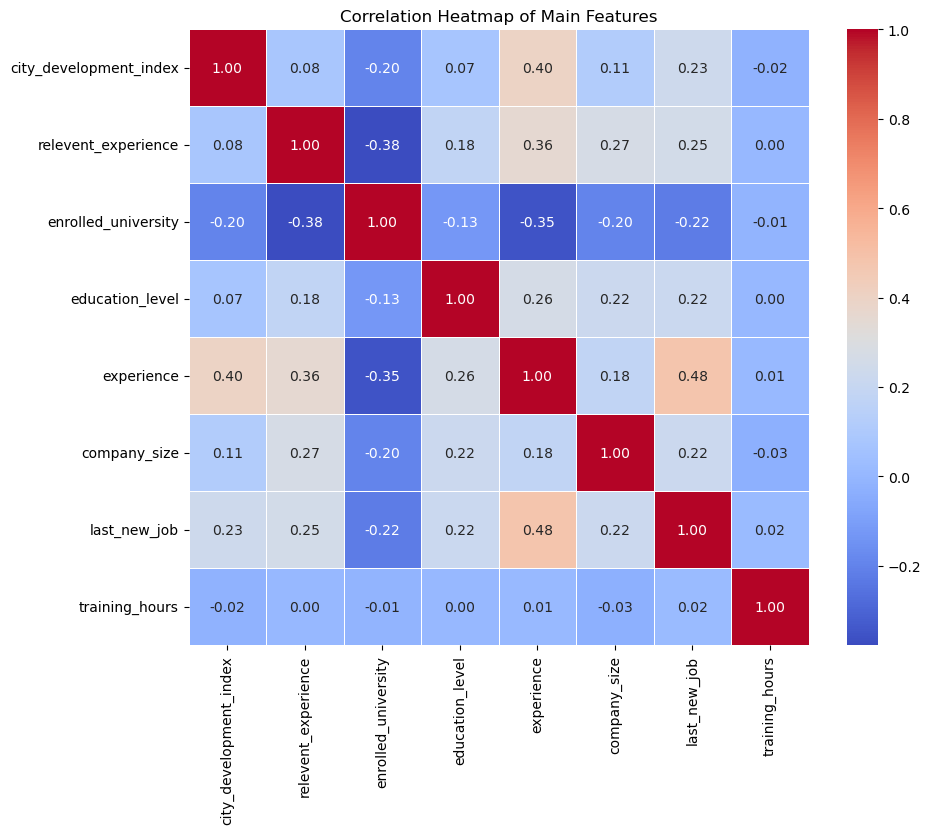

In [42]:
main_cols = ['city_development_index', 'relevent_experience', 'enrolled_university', 
             'education_level', 'experience', 'company_size', 'last_new_job', 'training_hours']

plt.figure(figsize=(10, 8))
sns.heatmap(df[main_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Main Features')
plt.show()

C:\Users\harsh\AppData\Local\Temp\ipykernel_19312\781423843.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='education_level', palette='viridis')


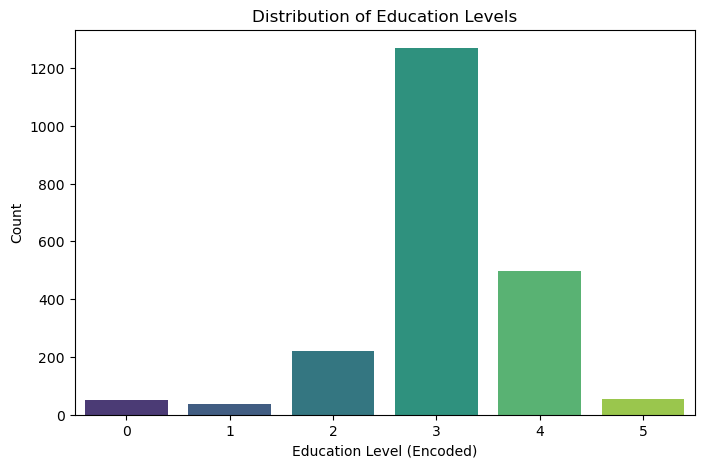

In [43]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='education_level', palette='viridis')
plt.title('Distribution of Education Levels')
plt.xlabel('Education Level (Encoded)')
plt.ylabel('Count')
plt.show()

In [44]:
from sklearn.preprocessing import StandardScaler

In [45]:
sclar = StandardScaler()

In [46]:
X_scaled = sclar.fit_transform(df)

In [47]:
df['Target'] = ((df['experience'] < 6) & (df['city_development_index'] < 0.82)).astype(int)

In [48]:
print("Target Variable Distribution:")
print(df['Target'].value_counts())

Target Variable Distribution:
Target
0    1733
1     396
Name: count, dtype: int64


In [49]:
X = df.drop(columns=['Target'])

In [50]:
y = df['Target']

In [51]:
from sklearn.model_selection import train_test_split

In [52]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [53]:
from sklearn.ensemble import RandomForestClassifier

In [54]:
model = RandomForestClassifier(n_estimators=100, random_state=42)



In [55]:
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [56]:
y_pred = model.predict(X_test)

In [57]:
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0,
       0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,

In [58]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix


In [59]:
print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.2%}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       347
           1       1.00      1.00      1.00        79

    accuracy                           1.00       426
   macro avg       1.00      1.00      1.00       426
weighted avg       1.00      1.00      1.00       426



In [60]:
importances = model.feature_importances_
feature_names = X.columns
feat_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)



C:\Users\harsh\AppData\Local\Temp\ipykernel_19312\3363923428.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_importances.values[:10], y=feat_importances.index[:10], palette='viridis')


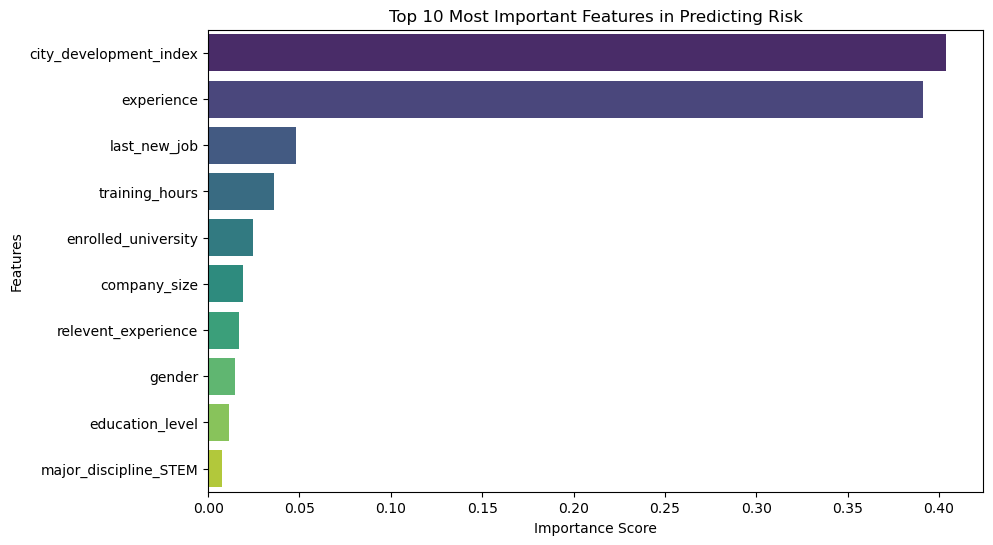

In [61]:
plt.figure(figsize=(10, 6))
sns.barplot(x=feat_importances.values[:10], y=feat_importances.index[:10], palette='viridis')
plt.title('Top 10 Most Important Features in Predicting Risk')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

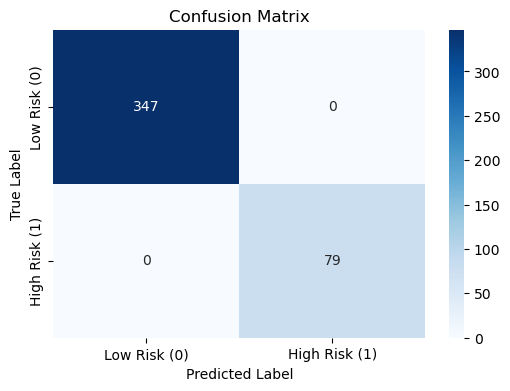

In [62]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Low Risk (0)', 'High Risk (1)'], 
            yticklabels=['Low Risk (0)', 'High Risk (1)'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [64]:
import joblib as jb

In [65]:
jb.dump(model,'rf_candidate_risk_model.pkl')

['rf_candidate_risk_model.pkl']

In [66]:
print("loaded ")

loaded 
